# Регрессия для SI

В этом ноутбуке решается задача регрессии для целевой переменной `SI`.

`SI` -> индекс селективности соединения.
Чем выше значение `SI`, тем более избирательным считается соединение относительно вирусной активности и цитотоксичности.

В качестве признаков используются молекулярные дескрипторы, очищенные по итогам EDA:

- удалены константные признаки
- удалены почти константные признаки
- удалены сильно коррелирующие признаки

Целевые переменные `IC50, mM`, `CC50, mM` и `SI` исключаются из признакового пространства, чтобы не допустить утечки данных.

# Импорты

In [45]:
# Библиотеки для работы с данными
import pandas as pd

# Разделение данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Загрузка данных
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import (
    load_coursework_dataset,
)

# Конфигурация проекта
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    METRICS_DIR,
    PREDICTIONS_DIR,
    RANDOM_STATE,
    TARGET_SI,
    TEST_SIZE,
)

# Подготовка признаков и целевой переменной
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_features,
    build_regression_target,
    preprocess_features,
)

# Фабрика моделей
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.model_factory import (
    get_regression_models,
)

# Запуск экспериментов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.experiment_runner import (
    run_regression_experiment,
)

# Визуализация
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.plotting import (
    plot_actual_vs_predicted,
    plot_feature_importance,
    plot_regression_results,
)

## Загрузка данных

Загрузим исходный датасет и проверим первые строки.

In [46]:
df = load_coursework_dataset()

print(f"Размер датасета: {df.shape}")

df.head()

Размер датасета: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


## Подготовка признаков и целевой переменной

Сформируем матрицу признаков `X` и целевую переменную `y`.

В качестве целевой переменной используется столбец `SI`.

Из признаков исключаются служебные столбцы и все целевые переменные: `IC50, mM`, `CC50, mM`, `SI`.

Цель -> не допустить утечки данных.

In [47]:
X = build_features(df)
y = build_regression_target(df, TARGET_SI)

print(f"Размер исходной матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")
print(f"Целевая переменная: {TARGET_SI}")

Размер исходной матрицы признаков X: (1001, 210)
Размер целевой переменной y: (1001,)
Целевая переменная: SI


## Базовая статистика целевой переменной

Посмотрим базовые статистики `SI`.

Это поможет оценить масштаб значений, асимметрию распределения и наличие крупных выбросов.

In [48]:
y.describe()

count     1001.000000
mean        72.508823
std        684.482739
min          0.011489
25%          1.433333
50%          3.846154
75%         16.566667
max      15620.600000
Name: SI, dtype: float64

## Предобработка признаков

По итогам EDA выполним очистку признакового пространства.

Удалим:

- константные признаки, у которых во всех строках одно и то же значение
- почти константные признаки, где одно значение встречается минимум в 99% строк
- сильно коррелирующие признаки, если абсолютная Spearman-корреляция между двумя признаками не ниже 0.90

Целевую переменную на этом этапе не изменяем.

In [49]:
X_clean, preprocessing_report = preprocess_features(X)

print(f"Размер матрицы признаков до обработки: {X.shape}")
print(f"Размер матрицы признаков после обработки: {X_clean.shape}")

print(f"Удалено константных признаков: {len(preprocessing_report['constant_features'])}")
print(f"Удалено почти константных признаков: {len(preprocessing_report['near_constant_features'])}")
print(f"Удалено сильно коррелирующих признаков: {len(preprocessing_report['highly_correlated_features'])}")
print(f"Всего удалено признаков: {len(preprocessing_report['removed_features'])}")

Размер матрицы признаков до обработки: (1001, 210)
Размер матрицы признаков после обработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76


In [50]:
# Сводка по предобработке
preprocessing_summary = pd.DataFrame(
    {
        "step": [
            "constant_features",
            "near_constant_features",
            "highly_correlated_features",
            "removed_features",
            "remaining_features",
        ],
        "count": [
            len(preprocessing_report["constant_features"]),
            len(preprocessing_report["near_constant_features"]),
            len(preprocessing_report["highly_correlated_features"]),
            len(preprocessing_report["removed_features"]),
            len(preprocessing_report["remaining_features"]),
        ],
    }
)

preprocessing_summary

,step,count
0,constant_features,18
1,near_constant_features,15
2,highly_correlated_features,43
3,removed_features,76
4,remaining_features,134


## Модели без логарифмирования целевой переменной

Сначала обучим модели на исходной целевой переменной `SI`.

Сравним несколько алгоритмов регрессии:

- DummyRegressor
- Linear Regression
- Ridge
- KNN
- SVR
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

In [51]:
regression_models = get_regression_models(use_log_target=False)

regression_models.keys()

dict_keys(['dummy_mean', 'linear_regression', 'ridge', 'knn', 'svr_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'catboost'])

## Запуск эксперимента без логарифмирования

In [52]:
si_results, si_fitted_models = run_regression_experiment(
    X=X_clean,
    y=y,
    models=regression_models,
)

si_results["feature_set"] = "preprocessed_features"
si_results["target_transform"] = "original"

si_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,random_forest,265.883173,112.430780,800,201,5.867010,191.277281,1353.767099,0.087617,11380.892690,preprocessed_features,original
1,hist_gradient_boosting,272.028417,111.738224,800,201,3.813402,191.704932,1354.653753,0.086421,10807.200818,preprocessed_features,original
2,extra_trees,273.670586,111.713504,800,201,1.995534,186.603646,1354.669961,0.086400,10518.730738,preprocessed_features,original
3,catboost,272.647143,111.251195,800,201,4.859584,189.004842,1355.603456,0.085140,10562.393974,preprocessed_features,original
4,knn,258.597464,122.685646,800,201,0.043010,195.795308,1356.430065,0.084024,11224.021979,preprocessed_features,original
5,linear_regression,268.883001,108.430573,800,201,0.037234,228.706924,1367.537993,0.068961,12527.475976,preprocessed_features,original
6,ridge,263.663693,109.875052,800,201,0.033590,222.864229,1368.428012,0.067748,12264.961889,preprocessed_features,original
7,dummy_mean,228.338418,159.240378,800,201,0.014767,204.718029,1423.936908,-0.009417,2598.922371,preprocessed_features,original
8,svr_rbf,223.611075,165.842344,800,201,0.104404,179.612237,1425.671512,-0.011878,584.277843,preprocessed_features,original


## Сохранение метрик без логарифмирования

In [53]:
si_results.to_csv(
    METRICS_DIR / "regression_si_metrics.csv",
    index=False,
)

si_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,random_forest,265.883173,112.430780,800,201,5.867010,191.277281,1353.767099,0.087617,11380.892690,preprocessed_features,original
1,hist_gradient_boosting,272.028417,111.738224,800,201,3.813402,191.704932,1354.653753,0.086421,10807.200818,preprocessed_features,original
2,extra_trees,273.670586,111.713504,800,201,1.995534,186.603646,1354.669961,0.086400,10518.730738,preprocessed_features,original
3,catboost,272.647143,111.251195,800,201,4.859584,189.004842,1355.603456,0.085140,10562.393974,preprocessed_features,original
4,knn,258.597464,122.685646,800,201,0.043010,195.795308,1356.430065,0.084024,11224.021979,preprocessed_features,original
5,linear_regression,268.883001,108.430573,800,201,0.037234,228.706924,1367.537993,0.068961,12527.475976,preprocessed_features,original
6,ridge,263.663693,109.875052,800,201,0.033590,222.864229,1368.428012,0.067748,12264.961889,preprocessed_features,original
7,dummy_mean,228.338418,159.240378,800,201,0.014767,204.718029,1423.936908,-0.009417,2598.922371,preprocessed_features,original
8,svr_rbf,223.611075,165.842344,800,201,0.104404,179.612237,1425.671512,-0.011878,584.277843,preprocessed_features,original


## График сравнения моделей без логарифмирования

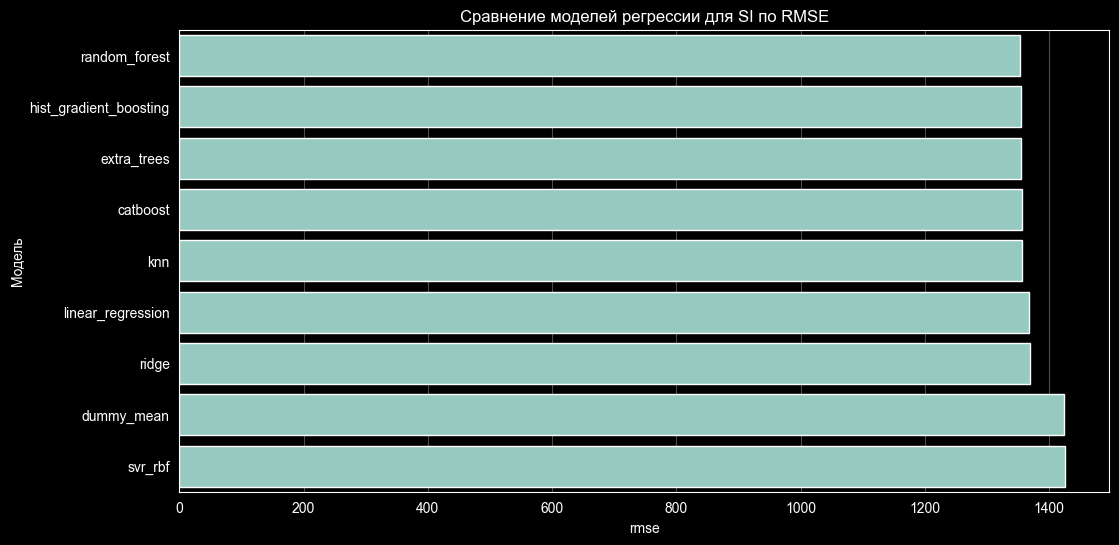

In [54]:
plot_regression_results(
    results_df=si_results,
    metric="rmse",
    title="Сравнение моделей регрессии для SI по RMSE",
)

## Модели с логарифмированием целевой переменной

Так как `SI` может иметь выраженную правостороннюю асимметрию и выбросы, дополнительно проверим вариант с логарифмированием целевой переменной.

Модели будут обучаться на `log1p(y)`, а предсказания будут автоматически возвращаться в исходный масштаб через обратное преобразование.

In [55]:
regression_log_models = get_regression_models(use_log_target=True)

regression_log_models.keys()

dict_keys(['dummy_mean_log_target', 'linear_regression_log_target', 'ridge_log_target', 'knn_log_target', 'svr_rbf_log_target', 'random_forest_log_target', 'extra_trees_log_target', 'hist_gradient_boosting_log_target', 'catboost_log_target'])

## Запуск эксперимента с логарифмированием

In [56]:
si_log_results, si_log_fitted_models = run_regression_experiment(
    X=X_clean,
    y=y,
    models=regression_log_models,
)

si_log_results["feature_set"] = "preprocessed_features"
si_log_results["target_transform"] = "log1p"

si_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,hist_gradient_boosting_log_target,223.774042,161.077924,800,201,2.435162,178.236252,1414.213471,0.004321,706.378272,preprocessed_features,log1p
1,random_forest_log_target,220.976094,164.298685,800,201,3.760978,177.608020,1414.368377,0.004103,658.761325,preprocessed_features,log1p
2,extra_trees_log_target,220.620236,164.453702,800,201,1.711894,177.675459,1414.435037,0.004009,651.092473,preprocessed_features,log1p
3,catboost_log_target,222.945456,161.965854,800,201,5.003146,178.000425,1416.104588,0.001657,652.390228,preprocessed_features,log1p
4,knn_log_target,222.090446,164.550126,800,201,0.034154,180.801233,1416.980007,0.000422,449.853846,preprocessed_features,log1p
5,svr_rbf_log_target,226.234360,159.565259,800,201,0.106441,178.578525,1422.838648,-0.007861,394.540700,preprocessed_features,log1p
6,linear_regression_log_target,231.979322,159.225868,800,201,0.035805,181.461802,1423.115429,-0.008253,784.114077,preprocessed_features,log1p
7,ridge_log_target,227.622698,158.862846,800,201,0.031583,180.279097,1423.649946,-0.009011,729.727283,preprocessed_features,log1p
8,dummy_mean_log_target,226.191257,165.739204,800,201,0.016276,181.414763,1428.123381,-0.015362,353.757486,preprocessed_features,log1p


## Сохранение метрик логарифмического эксперимента

In [57]:
si_log_results.to_csv(
    METRICS_DIR / "regression_si_log_target_metrics.csv",
    index=False,
)

si_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,hist_gradient_boosting_log_target,223.774042,161.077924,800,201,2.435162,178.236252,1414.213471,0.004321,706.378272,preprocessed_features,log1p
1,random_forest_log_target,220.976094,164.298685,800,201,3.760978,177.608020,1414.368377,0.004103,658.761325,preprocessed_features,log1p
2,extra_trees_log_target,220.620236,164.453702,800,201,1.711894,177.675459,1414.435037,0.004009,651.092473,preprocessed_features,log1p
3,catboost_log_target,222.945456,161.965854,800,201,5.003146,178.000425,1416.104588,0.001657,652.390228,preprocessed_features,log1p
4,knn_log_target,222.090446,164.550126,800,201,0.034154,180.801233,1416.980007,0.000422,449.853846,preprocessed_features,log1p
5,svr_rbf_log_target,226.234360,159.565259,800,201,0.106441,178.578525,1422.838648,-0.007861,394.540700,preprocessed_features,log1p
6,linear_regression_log_target,231.979322,159.225868,800,201,0.035805,181.461802,1423.115429,-0.008253,784.114077,preprocessed_features,log1p
7,ridge_log_target,227.622698,158.862846,800,201,0.031583,180.279097,1423.649946,-0.009011,729.727283,preprocessed_features,log1p
8,dummy_mean_log_target,226.191257,165.739204,800,201,0.016276,181.414763,1428.123381,-0.015362,353.757486,preprocessed_features,log1p


## График сравнения моделей с логарифмированием

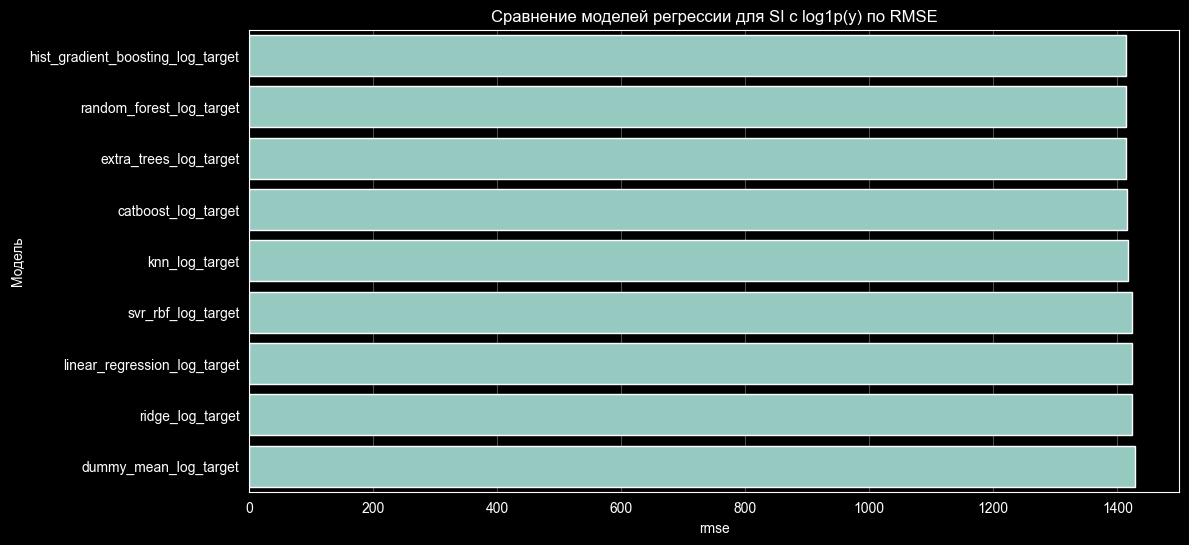

In [58]:
plot_regression_results(
    results_df=si_log_results,
    metric="rmse",
    title="Сравнение моделей регрессии для SI с log1p(y) по RMSE",
)

## Общее сравнение моделей

Объединим результаты экспериментов с исходной целевой переменной и с `log1p(y)`.

Лучшей моделью будем считать модель с минимальным значением `RMSE`.

In [59]:
si_all_results = (
    pd.concat(
        [
            si_results,
            si_log_results,
        ],
        ignore_index=True,
    )
    .sort_values(by=["rmse", "mae"], ascending=True)
    .reset_index(drop=True)
)

si_all_results.to_csv(
    METRICS_DIR / "regression_si_all_metrics.csv",
    index=False,
)

si_all_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,random_forest,265.883173,112.430780,800,201,5.867010,191.277281,1353.767099,0.087617,11380.892690,preprocessed_features,original
1,hist_gradient_boosting,272.028417,111.738224,800,201,3.813402,191.704932,1354.653753,0.086421,10807.200818,preprocessed_features,original
2,extra_trees,273.670586,111.713504,800,201,1.995534,186.603646,1354.669961,0.086400,10518.730738,preprocessed_features,original
3,catboost,272.647143,111.251195,800,201,4.859584,189.004842,1355.603456,0.085140,10562.393974,preprocessed_features,original
4,knn,258.597464,122.685646,800,201,0.043010,195.795308,1356.430065,0.084024,11224.021979,preprocessed_features,original
5,linear_regression,268.883001,108.430573,800,201,0.037234,228.706924,1367.537993,0.068961,12527.475976,preprocessed_features,original
6,ridge,263.663693,109.875052,800,201,0.033590,222.864229,1368.428012,0.067748,12264.961889,preprocessed_features,original
7,hist_gradient_boosting_log_target,223.774042,161.077924,800,201,2.435162,178.236252,1414.213471,0.004321,706.378272,preprocessed_features,log1p
8,random_forest_log_target,220.976094,164.298685,800,201,3.760978,177.608020,1414.368377,0.004103,658.761325,preprocessed_features,log1p
9,extra_trees_log_target,220.620236,164.453702,800,201,1.711894,177.675459,1414.435037,0.004009,651.092473,preprocessed_features,log1p


## График общего сравнения

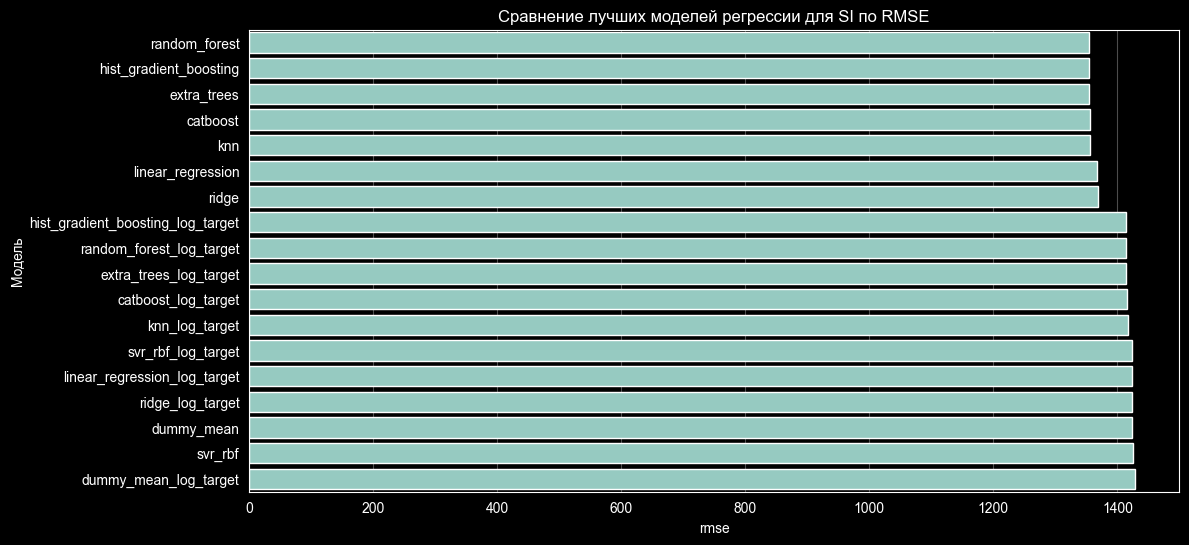

In [60]:
plot_regression_results(
    results_df=si_all_results,
    metric="rmse",
    title="Сравнение лучших моделей регрессии для SI по RMSE",
)

## Выбор лучшей модели

Выберем модель с минимальным значением `RMSE`.

Дополнительно посмотрим:

- набор признаков
- тип преобразования целевой переменной
- RMSE
- MAE
- R2
- MAPE

In [61]:
best_result = si_all_results.iloc[0]

best_result

model                       random_forest
cv_rmse_mean                   265.883173
cv_rmse_std                     112.43078
train_rows                            800
test_rows                             201
fit_time_sec                      5.86701
mae                            191.277281
rmse                          1353.767099
r2                               0.087617
mape                          11380.89269
feature_set         preprocessed_features
target_transform                 original
Name: 0, dtype: object

## Вывод названия лучшей модели

In [62]:
best_model_name = best_result["model"]
best_feature_set = best_result["feature_set"]
best_target_transform = best_result["target_transform"]

print(f"Лучшая модель: {best_model_name}")
print(f"Набор признаков: {best_feature_set}")
print(f"Преобразование целевой переменной: {best_target_transform}")
print(f"RMSE: {best_result['rmse']:.4f}")
print(f"MAE: {best_result['mae']:.4f}")
print(f"R2: {best_result['r2']:.4f}")
print(f"MAPE: {best_result['mape']:.4f}")

Лучшая модель: random_forest
Набор признаков: preprocessed_features
Преобразование целевой переменной: original
RMSE: 1353.7671
MAE: 191.2773
R2: 0.0876
MAPE: 11380.8927


## Получение лучшей обученной модели

In [63]:
if best_target_transform == "original":
    best_model = si_fitted_models[best_model_name]
else:
    best_model = si_log_fitted_models[best_model_name]

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## Предсказания лучшей модели

Повторим разбиение на train/test с теми же параметрами, которые используются внутри `run_regression_experiment`.

Это нужно, чтобы получить предсказания лучшей модели именно на тестовой выборке.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

y_pred = best_model.predict(X_test)

best_predictions = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

best_predictions.to_csv(
    PREDICTIONS_DIR / "regression_si_best_predictions.csv",
    index=False,
)

best_predictions.head()

,y_true,y_pred
521,1.000000,15.040934
941,6.055648,3.803578
741,9.580153,5.719294
980,1.172419,30.630039
411,3.157895,3.858751


## График фактических и предсказанных значений

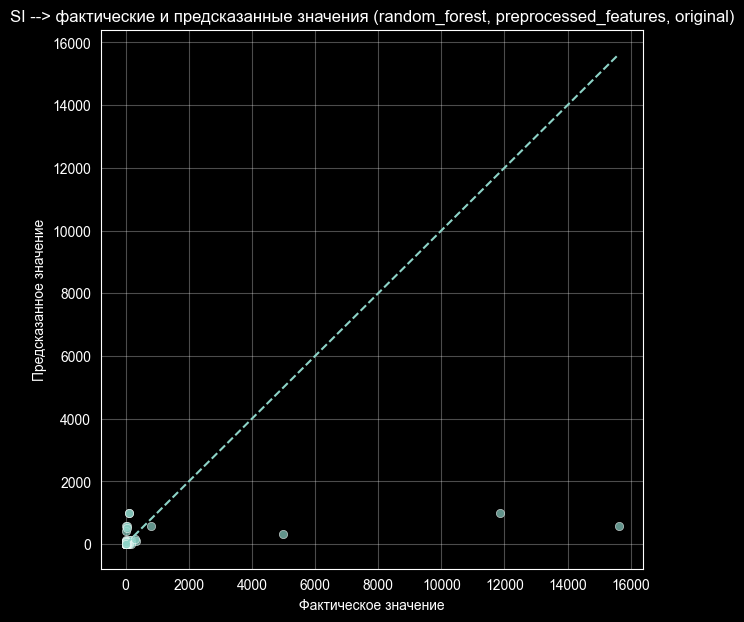

In [65]:
plot_actual_vs_predicted(
    y_true=best_predictions["y_true"],
    y_pred=best_predictions["y_pred"],
    title=(
        f"SI --> фактические и предсказанные значения "
        f"({best_model_name}, {best_feature_set}, {best_target_transform})"
    ),
)

## Важность признаков

Для лучшей модели попробуем вывести важность признаков.

### Примечание

Этот блок работает только для моделей, который поддерживают атрибут `feature_importances_`:
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

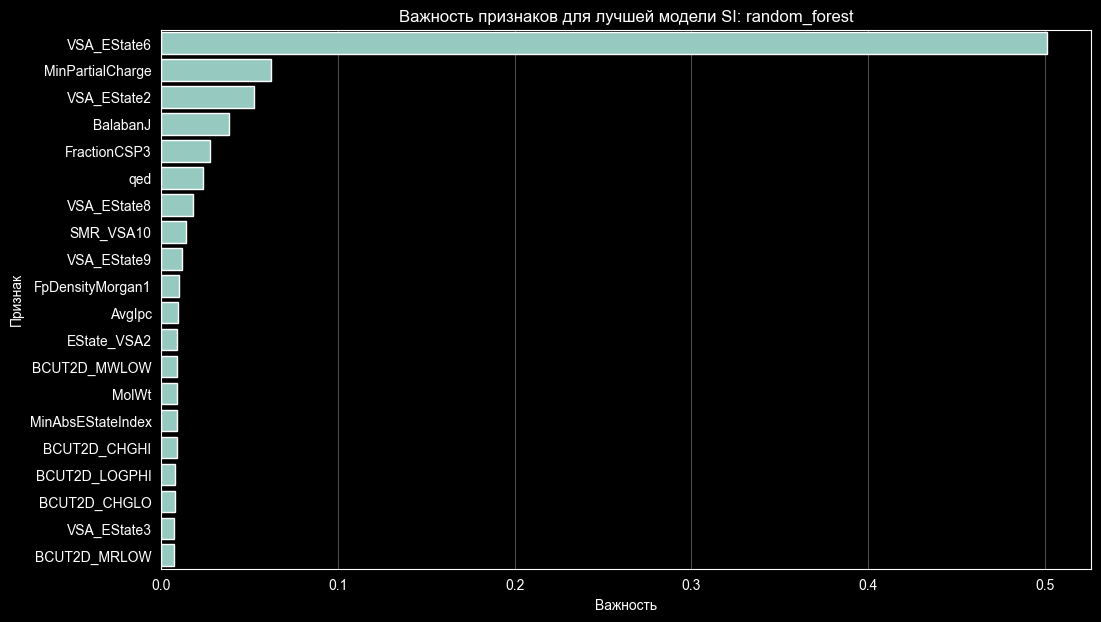

In [66]:
try:
    si_feature_importance = plot_feature_importance(
        model=best_model,
        feature_names=X_clean.columns.tolist(),
        top_n=20,
        title=f"Важность признаков для лучшей модели SI: {best_model_name}",
    )

    si_feature_importance.to_csv(
        METRICS_DIR / "regression_si_feature_importance.csv",
        index=False,
    )

    si_feature_importance.head(20)

except ValueError as error:
    print(error)

# Вывод по задаче регрессии SI

Для прогнозирования показателя SI были обучены несколько моделей регрессии:
- DummyRegressor
- Линейная регрессия
- Ridge
- KNN
- SVR
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

Обучение выполнялось на предобработанном наборе признаков.
По итогам EDA из признакового пространства были удалены:

* 18 константных признаков
* 15 почти константных признаков
* 43 сильно коррелирующих признака
* всего удалено 76 признаков

После предобработки размер матрицы признаков уменьшился с (1001, 210) до (1001, 134).

Целевая переменная SI имеет крайне выраженную правостороннюю асимметрию.
Медианное значение составляет около 3.85, среднее значение около 72.51,
при этом максимальное значение достигает 15620.60.
Это говорит о наличии очень крупных выбросов, которые сильно усложняют задачу регрессии.

Были проверены два варианта обучения:

1. обучение на исходной целевой переменной
2. обучение на логарифмированной целевой переменной log1p(y) с последующим обратным преобразованием предсказаний

По итогам сравнения лучшей моделью стала RandomForestRegressor, обученная на исходной целевой переменной и предобработанных признаках.

Основные метрики лучшей модели:

* RMSE: 1353.7671
* MAE: 191.2773
* R2: 0.0876
* MAPE: 11380.8927

Несмотря на то, что RandomForestRegressor показал минимальное значение RMSE среди обученных моделей,
итоговое качество нельзя назвать высоким.
Значение R2 = 0.0876 означает, что модель объясняет только около 8.8% вариативности целевой переменной на тестовой выборке.

На графике фактических и предсказанных значений видно, что модель плохо восстанавливает экстремально большие значения SI.
Для объектов с очень высоким фактическим SI прогнозы оказываются сильно заниженными.
Это ожидаемо, так как в выборке большинство объектов имеет небольшие значения SI, а крупные выбросы встречаются редко.

Логарифмирование целевой переменной не улучшило качество по ключевой метрике RMSE в исходном масштабе.
Модели с log1p(y) давали более низкие значения MAE и MAPE, но по RMSE уступили лучшей модели на исходной целевой переменной.
Поэтому в качестве основной модели для задачи регрессии SI выбран RandomForestRegressor без логарифмирования целевой переменной.

Анализ важности признаков показал, что наибольший вклад в прогноз модели внес признак `VSA_EState6`.
Его важность существенно выше остальных признаков, поэтому модель в значительной степени опирается именно на него.
Среди других значимых признаков также выделяются `MinPartialCharge`, `VSA_EState2`, `BalabanJ`, `FractionCSP3`, `qed` и ряд `BCUT2D/VSA-дескрипторов`.

### Итог

Задача регрессии SI оказалась наиболее сложной среди рассмотренных регрессионных задач
из-за сильной асимметрии распределения и редких экстремальных значений.
Модель может улавливать общие закономерности для малых и средних значений SI, но не обеспечивает надежного прогноза для крупных выбросов.
Для последующих задач классификации по SI такой результат важен,
бинарная постановка может оказаться более устойчивой, чем попытка точно предсказывать численное значение SI.